Notebook 2: BERT repair

This notebook builds and checks repairing using finetuned `bert-base-cased`.
We fine-tuned it on clean text, which fills the damaged words of a sentence from left to right and picks each word by BERT's score plus its letter similarity to the damaged form. 

**Input.** The frozen damaged dataset `data/processed/corrupted_v2.jsonl` (hash checked against
`runs/corrupted_v2.sha256`), the sample `data/processed/sentences.jsonl`, BLN600 in `data/raw/BLN600/`,
`configs/config.yaml`, and the fine-tuned model `models/bert_ft_v1/` with its run record in `runs/`.

**Output.** The training pool `data/processed/bert_train_pool.jsonl` with its hash, and the stored
predictions of the pipeline check and of the repair run on the split in `runs/preds/` (scored in notebook 4).

The fine-tuning is separately run on cloud resource, model is then downloaded and used locally.

In [1]:
import pandas as pd
import transformers
from transformers import AutoModelForMaskedLM, AutoTokenizer

transformers.logging.set_verbosity_error()  # keep model loading messages out of the outputs
transformers.logging.disable_progress_bar()

# blnrepair is self developed for this project: data loading, damage, and the repair pipeline.
from blnrepair.data import ROOT, load_config
from blnrepair.freeze import load_frozen

pd.set_option("display.max_colwidth", None)
config = load_config()
LEVELS = ["0"] + [str(level) for level in config["corruption"]["levels"]]  # YAML reads 10 as a number
rows = load_frozen("v2")  # stops if the file hash does not match runs/corrupted_v2.sha256

D:\UR_Lectures\GenAI_proj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


view input

Both repair methods get exactly the same input. The undamaged words stay as they are, and every damaged
gold word becomes one **slot** showing its damaged form, written `⟨...⟩`. A word that was dropped
completely is an empty slot `⟨?⟩`, so both methods know how many words are missing. The slot view is
built from the gold words and the damage plan of each word.

In [2]:
from blnrepair.slots import build_slots, row_counts, slot_view, splice

dev_id = next(r["id"] for r in rows if r["split"] == "dev")
examples = [r for r in rows if r["id"] == dev_id and r["severity"] in ("1w", "25", "75")]
pd.DataFrame({"level": [r["severity"] for r in examples], "slots": [r["k"] for r in examples],
              "slot view": [slot_view(build_slots(r)) for r in examples],
              "gold span": [" ".join(r["gold_tokens"][r["span_start"]:r["span_end"]]) for r in examples]})

,level,slots,slot view,gold span
0,1w,1,"It was ascertained that he had hired a bicycle at Aberdeen, and had ridden from there to Perth, where, it was asserted, he sold the bicycle for ⟨£1,⟩ and then came to London with the money.","£2,"
1,25,9,"It was ascertained that he had hired a bicycle at Aberdeen, and had ridden from there to Perth, where, it was asserted, he ⟨so1d⟩ ⟨tbe⟩ ⟨icyclc⟩ ⟨tor⟩ ⟨£1,⟩ ⟨aud⟩ ⟨bhen⟩ ⟨eame⟩ ⟨bo⟩ London with the money.","sold the bicycle for £2, and then came to"
2,75,27,"It was ascertained that he had hired a bicycle ⟨ab⟩ ⟨?⟩ ⟨?⟩ ⟨?⟩ ⟨ridde⟩ ⟨rom⟩ ⟨thre⟩ ⟨bo⟩ ⟨Porth,⟩ ⟨?⟩ ⟨It⟩ ⟨wae⟩ ⟨assetod,⟩ ⟨e⟩ ⟨so1d⟩ ⟨tbe⟩ ⟨icyclc⟩ ⟨tor⟩ ⟨£1,⟩ ⟨aud⟩ ⟨bhen⟩ ⟨eame⟩ ⟨bo⟩ ⟨Loidou⟩ ⟨witb⟩ ⟨tbe⟩ ⟨nioney.⟩","at Aberdeen, and had ridden from there to Perth, where, it was asserted, he sold the bicycle for £2, and then came to London with the money."


Rows by split and level. Level 0 is the clean sentence and has no slots, so both methods skip it.

Prediction store

Every prediction of both methods is stored in `runs/preds/<method>_<version>.jsonl`, one line per row
and level; the file is only appended to and a stored row is skipped, so a stopped run resumes without
repeating work. 

In [3]:
from blnrepair.preds import load_preds, pred_path, run_method, slot_exact


Training data

BERT is fine-tuned as a masked language model on clean gold text only. It never sees damaged text in
training; the damaged letters enter only later, when candidate words are scored.

The training sentences come only from excerpts outside the 157 excerpts of the test and dev sample,
because names repeat within an excerpt. The 29 calibration excerpts from notebook 1 are allowed: they
only shaped the table of OCR confusions, not the test data. Sentences are cut with the same splitter as in
notebook 1 and kept if they have 20 to 60 words and at least 1 fact token (the masked block is centred
on a fact token). 10% of the training excerpts are held out, by excerpt, to measure the validation loss.
The dev split is never used for that. The pool is rebuilt here from the raw corpus, and `build_pool`
stops if a training sentence shares an excerpt or its exact text with the sample.

In [4]:
from blnrepair.bert_data import build_pool, freeze_pool

pool, sample, summary = build_pool(config)
display(summary)
print("sentences by length band and use:")
pd.crosstab(pool["band"].astype(str), pool["usage"], margins=True)


,sentences,excerpts,words
usage,,,
train,2635,396,86856
val,304,44,9936
total,2939,440,96792


sentences by length band and use:


usage,train,val,All
band,,,
20-29,1223,150,1373
30-44,1015,103,1118
45-60,397,51,448
All,2635,304,2939


The pool is written with its hash, which the fine-tuning script checks before training. If the file
already exists, the rebuilt pool must be identical to it, otherwise the notebook stops: a model may
already have been trained on the old pool.

In [5]:
status, digest = freeze_pool(pool, ROOT / "data/processed/bert_train_pool.jsonl", ROOT / "runs/bert_train_pool.sha256")
print(f"bert_train_pool.jsonl: {status}, sha256 {digest}")

bert_train_pool.jsonl: unchanged, sha256 d5313c92a49b12de10a07807705dcb9ae8b245cbe7fa94249074188ff15935ae


**Masking.** Each training sentence gets one masked block per epoch, drawn like the evaluation damage: a level among
1w, 10, 25, 50 and 75% of the sentence's words, the same rounding and clamping as notebook 1, and a
random fact token as anchor. Training sentences get a new draw every epoch; validation sentences keep one
fixed draw, so the validation loss can be compared between epochs.

The training input copies what BERT sees during repair, where slots are filled from left to right. For
each word of the block there is one example: the block's words before it are shown as gold (already
filled), the word itself is masked with its true number of pieces (the loss is computed only there), and
the block's words after it show one `[MASK]` each, as a slot still waiting to be filled. Punctuation
around the words stays visible, as in the slot view. Three inputs from epoch 0:

In [6]:
from blnrepair.bert_data import epoch_examples, example_stats

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
epoch0 = list(epoch_examples(pool, config["seed"], 0, tokenizer.tokenize))
picks = [("3200797029-002", 0), ("3200797029-001", 34), ("3200797029-001", 12)]
shown = [e for key in picks for e in epoch0 if (e["id"], e["target_pos"]) == key]
pd.DataFrame({"level": [e["level"] for e in shown], "target": [e["target_word"] for e in shown],
              "pieces": [" ".join(tokenizer.tokenize(e["target_word"])) for e in shown],
              "training input": [e["masked_input"] for e in shown]})

,level,target,pieces,training input
0,25,Chief,Chief,"[MASK] [MASK] [MASK] [MASK] [MASK] were a number of charges against the prisoner, all the robberies alleged being under similar circumstances."
1,75,Belgravia,Bel ##gra ##via,"EDWARD PRING, twenty-seven, carpenter, was brought up on remand at the Greenwich Police-court, charged with stealing jewellery to the value of £100, the property of Sir Robert Cunliffe, Bart., M.P., of 37 Lowndes street, [MASK] [MASK] [MASK]."
2,75,Police-court,Police - court,"EDWARD PRING, twenty-seven, carpenter, was brought up on remand at the Greenwich [MASK] [MASK] [MASK], [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] £[MASK], [MASK] [MASK] [MASK] [MASK] [MASK] [MASK], [MASK]., [MASK]., [MASK] [MASK] [MASK] [MASK], [MASK]."


The level is drawn once per sentence, so each level gets about the same number of sentences. But a
sentence gives one example per word of its block, so the large levels give most of the training examples
(table below). This weighting is kept on purpose: the one-word case is what pretrained BERT already does,
and the last word of every block gives that input anyway (about 1 example in 11).


In [7]:
pd.Series(example_stats(epoch0, tokenizer)["train_share_by_level"]).rename_axis("level").rename("share of training examples").to_frame().T


level,1w,10,25,50,75
share of training examples,0.019,0.055,0.156,0.31,0.461


Fine-tuning (separate script, not run here)

The fine-tuning is in `scripts/train_bert.py` with the settings in `configs/bert_ft.yaml`. It needs a GPU,
so it ran once on a Google Colab GPU and is not repeated by this notebook. It trains `bert-base-cased` on
the training examples above (the loss counts only the target word's masks), measures the validation loss
after every epoch, stops after 2 epochs without improvement (at most 10), and keeps the best epoch.
Settings: learning rate 5e-5, batch 16, warmup over the first 10% of an epoch then a linear decrease,
weight decay 0.01, mixed precision on the GPU. Below, the notebook only reads the record of that run and
checks that it was trained on the pool built above.

trained on Tesla T4, 4 epochs (early stop: no lower validation loss for 2 epochs), best epoch 2
validation loss per target piece: pretrained 5.61 -> fine-tuned 4.14


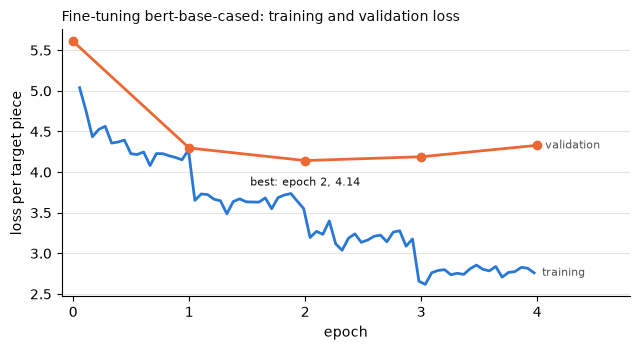

In [8]:
import yaml
from blnrepair.plots import loss_curve

run = yaml.safe_load((ROOT / "runs/bert_ft_v1_config.yaml").read_text(encoding="utf-8"))
assert run["pool_hash"] == digest, "the model was trained on a different pool than the one built above"
print(f"trained on {run['device']}, {run['epochs_run']} epochs ({run['stop_reason']}), best epoch {run['best_epoch']}")
print(f"validation loss per target piece: pretrained {run['pretrained_val_loss']:.2f} -> fine-tuned {run['best_val_loss']:.2f}")
log = pd.read_csv(ROOT / "runs/bert_ft_v1_log.csv")
fig = loss_curve(log, run["steps_per_epoch"], run["best_epoch"])


The validation loss falls in the first two epochs and then rises while the training loss keeps falling:
the model starts to memorise the training sentences, which come back every epoch with new masks (hence
the steps in the training curve at each epoch). Early stopping keeps epoch 2.

Repair: filling the slots with BERT

BERT fills the slots of a sentence from left to right; a slot that is still waiting shows one `[MASK]`.
For the current slot, BERT gets 1, 2 and 3 masks, because it is not told how many pieces the word has.
From its top 5 pieces per mask it builds candidate words (the 10 best per mask count). Each candidate
then gets a score:

*score = BERT's mean log-probability per piece + λ × letter similarity to the damaged form*

The letter similarity is 1 minus the edit distance divided by the longer length, so the damaged letters
count only here, never in training. A dropped slot has no letters: only BERT's score counts, and only
there a punctuation mark is a valid answer. A slot with a visible inner hyphen or apostrophe is filled
part by part. Settings for the check below: λ = 1, 5 pieces per mask, 10 candidates per mask count. They
are tuned on dev later. The two functions that do the work:

In [9]:
from blnrepair.bert_repair import BertReranker

Pipeline check on dev

**Not a result.** 5 dev sentences (2, 2 and 1 from the three length bands) at levels 1w, 25 and 75,
repaired once with plain `bert-base-cased` and once with the fine-tuned model. Every prediction goes
through the prediction store, so rerunning this notebook reads the stored rows.

In [10]:
dev0 = [r for r in rows if r["split"] == "dev" and r["severity"] == "0"]
quota, check_ids = {"20-29": 2, "30-44": 2, "45-60": 1}, []
for r in dev0:
    if quota[r["band"]]:
        quota[r["band"]] -= 1
        check_ids.append(r["id"])
check_rows = [r for r in rows if r["id"] in check_ids and r["severity"] in ("1w", "25", "75")]
versions = {"base-check-v2": "bert-base-cased", "ftv1-check-v2": ROOT / "models/bert_ft_v1"}
for version, source in versions.items():
    if len(load_preds(pred_path("bert_rerank", version))) < len(check_rows):
        reranker = BertReranker(AutoModelForMaskedLM.from_pretrained(source), AutoTokenizer.from_pretrained(source), lam=1.0, beam=5, top_n=10)
        run_method(check_rows, reranker, "bert_rerank", version, str(source))
stored = {v: {(p["id"], p["severity"]): p for p in load_preds(pred_path("bert_rerank", v))} for v in versions}
base, ft = stored["base-check-v2"], stored["ftv1-check-v2"]
table = pd.DataFrame([{
    "level": r["severity"],
    "gold span": " ".join(r["gold_tokens"][r["span_start"]:r["span_end"]]),
    "slot view (span)": " ".join(slot_view(build_slots(r)).split()[r["span_start"]:r["span_end"]]),
    "plain BERT": " ".join(base[(r["id"], r["severity"])]["pred_words"]),
    "fine-tuned": " ".join(ft[(r["id"], r["severity"])]["pred_words"]),
    "exact (plain)": round(slot_exact(base[(r["id"], r["severity"])]["pred_words"], r), 2),
    "exact (fine-tuned)": round(slot_exact(ft[(r["id"], r["severity"])]["pred_words"], r), 2),
    "seconds (fine-tuned)": ft[(r["id"], r["severity"])]["seconds"]} for r in check_rows])
table

,level,gold span,slot view (span),plain BERT,fine-tuned,exact (plain),exact (fine-tuned),seconds (fine-tuned)
0,1w,"£2,","⟨£1,⟩",10050,1s,0.00,0.00,0.825
1,25,"sold the bicycle for £2, and then came to","⟨so1d⟩ ⟨tbe⟩ ⟨icyclc⟩ ⟨tor⟩ ⟨£1,⟩ ⟨aud⟩ ⟨bhen⟩ ⟨eame⟩ ⟨bo⟩",had to pay for 10050 and then return to,had been finedly fined 1s and had beend to,0.44,0.22,7.988
2,75,"at Aberdeen, and had ridden from there to Perth, where, it was asserted, he sold the bicycle for £2, and then came to London with the money.","⟨ab⟩ ⟨?⟩ ⟨?⟩ ⟨?⟩ ⟨ridde⟩ ⟨rom⟩ ⟨thre⟩ ⟨bo⟩ ⟨Porth,⟩ ⟨?⟩ ⟨It⟩ ⟨wae⟩ ⟨assetod,⟩ ⟨e⟩ ⟨so1d⟩ ⟨tbe⟩ ⟨icyclc⟩ ⟨tor⟩ ⟨£1,⟩ ⟨aud⟩ ⟨bhen⟩ ⟨eame⟩ ⟨bo⟩ ⟨Loidou⟩ ⟨witb⟩ ⟨tbe⟩ ⟨nioney.⟩","and the "" A Cns Ar R S Plr a former railway engineer had to pay him for 1005 000 and the B R S Pp Ltdrd",and a van to carryob on the Sunday nights and at the time he had been ining for 1s and was ining for as much as 5s,0.04,0.11,21.894
3,1w,Railway-station,⟨Raiiy-ststion⟩,bus-station,Police-station,0.00,0.00,1.558
4,25,was at the Southend Railway-station the morning after,⟨wa⟩ ⟨et⟩ ⟨tho⟩ ⟨Southon⟩ ⟨Raiiy-ststion⟩ ⟨bhe⟩ ⟨merning⟩ ⟨aftet⟩,was not the only police-con manter present at,was noting that the prisonerstable-constable were notiring of,0.25,0.12,7.380
5,75,"Police-constable Prime said he was at the Southend Railway-station the morning after the robbery, and although he knew nothing of the theft he","⟨Pollce-constebls⟩ ⟨Prine⟩ ⟨ssid⟩ ⟨ho⟩ ⟨wa⟩ ⟨et⟩ ⟨tho⟩ ⟨Southon⟩ ⟨Raiiy-ststion⟩ ⟨bhe⟩ ⟨merning⟩ ⟨aftet⟩ ⟨thc⟩ ⟨rohberv,⟩ ⟨ancl⟩ ⟨altiongh⟩ ⟨lie⟩ ⟨kaew⟩ ⟨uobhing⟩ ⟨ot⟩ ⟨th⟩ ⟨thet⟩ ⟨ie⟩",the-the the the the the the the the the-the the the the the the the the the the the the the the they,Inspector-P said that he was noting that the prisonerstable-constablestable was notinging the disturbanceiring thes and that he saw the prisonerstablestable and Constablestablestable Fe,0.17,0.17,16.236
6,1w,"Market-place,","⟨NIaruet-plece,⟩",Oxford-street,Uppers-place,0.00,0.00,2.146
7,25,"occupier of a house, No. 12, Market-place, Oxford-street, on the site of the","⟨ocoupie⟩ ⟨ot⟩ ⟨?⟩ ⟨honse,⟩ ⟨Uo.⟩ ⟨?⟩ ⟨NIaruet-plece,⟩ ⟨Oforcl-sbteet,⟩ ⟨an⟩ ⟨tbe⟩ ⟨sIte⟩ ⟨af⟩ ⟨?⟩","sameee of the otheree Mr ,ee ande-andee ande-andee and aeee of the great",landlord of a house No 9 Souths-place Tottenham-square and was included in the,0.08,0.38,15.213
8,75,"Mr. Poland it appeared that for some years past the prisoner was the occupier of a house, No. 12, Market-place, Oxford-street, on the site of the old Oxford-street Market, and complaints were made to the vestry as to","⟨?⟩ ⟨?⟩ ⟨ib⟩ ⟨appsarecl⟩ ⟨thab⟩ ⟨fer⟩ ⟨eome⟩ ⟨vears⟩ ⟨pasb⟩ ⟨bhe⟩ ⟨prlsoser⟩ ⟨wes⟩ ⟨tho⟩ ⟨ocoupie⟩ ⟨ot⟩ ⟨?⟩ ⟨honse,⟩ ⟨Uo.⟩ ⟨?⟩ ⟨NIaruet-plece,⟩ ⟨Oforcl-sbteet,⟩ ⟨an⟩ ⟨tbe⟩ ⟨sIte⟩ ⟨af⟩ ⟨?⟩ ⟨?⟩ ⟨Olford-gtrect⟩ ⟨Msrkt,⟩ ⟨?⟩ ⟨conpiainte⟩ ⟨?⟩ ⟨mede⟩ ⟨te⟩ ⟨bhe⟩ ⟨veetry⟩ ⟨ae⟩ ⟨?⟩","the house is called the house of the house the house is called the house of house etc , house-house house-house house house house house , house house-house house house house house house house house house is called",the prisonerroner he was noting that the prisoner was aing of the mostco knownlyly in the county Mr John Gn-Gnl aer-maker was alsoinged on the premises of then-Constable Mnl and that he would not doubt the fact of,0.05,0.03,41.807
9,1w,Haines,⟨Hainos⟩,Henry,John,0.00,0.00,0.514


Share of slots restored exactly, and seconds per row, by level (sanity check on 5 sentences, not a result):

In [11]:
table.groupby("level", sort=False)[["exact (plain)", "exact (fine-tuned)", "seconds (fine-tuned)"]].mean().round(2)

,exact (plain),exact (fine-tuned),seconds (fine-tuned)
level,,,
1w,0.00,0.0,1.14
25,0.15,0.2,7.56
75,0.08,0.1,20.39


Repair run on the split

The fine-tuned model repairs every row of the split that has slots (all five damage levels), with the
settings in `configs/bert_repair.yaml`: λ = 8, chosen on dev below, with 5 pieces per mask and 10
candidates per mask count. The settings are part of the stored version name, so a run with other settings
is stored separately. The answers go to the same prediction store as the LLM's, and notebook 4 scores both. A stored
row is never repaired again, so rerunning this notebook takes seconds once the run is complete.
`SPLIT` chooses the rows (`dev` or `test`); the test split needs `frozen: true` in
`configs/bert_repair.yaml` and `ALLOW_TEST = True`. The λ grid below always uses dev.

In [12]:
from blnrepair.bert_repair import load_repair_config, repair_version

SPLIT, ALLOW_TEST = "test", True
repair_cfg = load_repair_config()
if SPLIT == "test":
    assert ALLOW_TEST and repair_cfg["frozen"], "the test split is closed: set ALLOW_TEST and freeze configs/bert_repair.yaml"
version = repair_version(repair_cfg, SPLIT)
split_rows = [r for r in rows if r["split"] == SPLIT]
todo = sum(1 for r in split_rows if r["k"]) - len(load_preds(pred_path("bert_rerank", version)))
if todo:
    source = ROOT / repair_cfg["model"]
    reranker = BertReranker(AutoModelForMaskedLM.from_pretrained(source), AutoTokenizer.from_pretrained(source),
                            lam=repair_cfg["lam"], beam=repair_cfg["beam"], top_n=repair_cfg["top_n"])
    run_method(split_rows, reranker, "bert_rerank", version, repair_cfg["model"], allow_test=ALLOW_TEST)
run = pd.DataFrame(load_preds(pred_path("bert_rerank", version)))
print(f"bert_rerank {version}: {len(run)} rows stored ({todo} repaired in this run)")
run.groupby("severity")["seconds"].agg(["size", "mean", "sum"]).reindex(LEVELS[1:]).round(1) \
   .rename(columns={"size": "rows", "mean": "seconds per row", "sum": "seconds in total"})

bert_rerank ftv1-l8-b5-n10-test: 750 rows stored (0 repaired in this run)


,rows,seconds per row,seconds in total
severity,,,
1w,150,0.7,99.0
10,150,2.3,343.8
25,150,5.6,842.5
50,150,11.2,1673.4
75,150,16.7,2501.4


Choosing λ on dev

λ sets how much the letters of the damaged word count against BERT's reading of the context. With λ = 1 the
context wins too often: for `⟨Merch⟩` BERT's candidates include `March` (letter similarity 0.8), but
`October` (similarity 0) has the better context score and is chosen. The grid repairs all dev rows with
λ = 1, 2, 4, 8 and 16 (5 pieces per mask and 10 candidates per mask count stay fixed); each setting is a
full run of about 13 minutes on a laptop CPU and is stored like any other run. The table scores each
setting on letter-level measures that need no extra model: exact words, Fact Recovery Rate, CER of the
span after repair, and repair gain. The chosen λ is written into `configs/bert_repair.yaml`; notebook 4
then scores that run. The dev split is used for this choice only; the test split is never used to choose.

In [13]:
from rapidfuzz.distance import Levenshtein
from blnrepair.slots import slot_core

GRID = [1, 2, 4, 8, 16]
dev_rows = [r for r in rows if r["split"] == "dev"]  # the grid is always on dev: the test split never chooses a setting
source = ROOT / repair_cfg["model"]
model, tokenizer = AutoModelForMaskedLM.from_pretrained(source), AutoTokenizer.from_pretrained(source)
grid_versions = {lam: repair_version({**repair_cfg, "lam": lam}, "dev") for lam in GRID}
for lam, version in grid_versions.items():
    if len(load_preds(pred_path("bert_rerank", version))) < sum(1 for r in dev_rows if r["k"]):
        reranker = BertReranker(model, tokenizer, lam=lam, beam=repair_cfg["beam"], top_n=repair_cfg["top_n"])
        run_method(dev_rows, reranker, "bert_rerank", version, repair_cfg["model"])  # allow_test stays False


def letter_scores(row, words):
    # exact words, fact recovery and span CER before / after for one repaired row
    plans = sorted(row["ops_per_word"], key=lambda p: p["idx"])
    s, e = row["span_start"], row["span_end"]
    span = {"gold_tokens": row["gold_tokens"][s:e], "ops_per_word": [{**p, "idx": p["idx"] - s} for p in plans]}
    gold_span = " ".join(row["gold_tokens"][s:e])
    cer = lambda text: Levenshtein.distance(text, gold_span) / len(gold_span)
    facts = [slot_core(w) == slot_core(p["gold"]) for w, p in zip(words, plans) if p["idx"] in row["fact_idx_in_span"]]
    return {"exact": slot_exact(words, row), "fact recovery": sum(facts) / len(facts),
            "CER before": cer(splice(span, [p["out"] for p in plans])), "CER after": cer(splice(span, words))}


by_key = {(r["id"], r["severity"]): r for r in rows}
grid = pd.DataFrame([{"λ": lam, "level": p["severity"], **letter_scores(by_key[(p["id"], p["severity"])], p["pred_words"])}
                     for lam, version in grid_versions.items() for p in load_preds(pred_path("bert_rerank", version))])
grid["repair gain"] = grid["CER before"] - grid["CER after"]
grid.groupby("λ")[["exact", "fact recovery", "CER after", "repair gain"]].mean().round(3)

,exact,fact recovery,CER after,repair gain
λ,,,,
1,0.164,0.042,0.756,-0.453
2,0.212,0.092,0.671,-0.368
4,0.239,0.116,0.604,-0.301
8,0.267,0.126,0.572,-0.269
16,0.263,0.128,0.570,-0.267


Fact Recovery Rate by λ and level:

In [14]:
grid.pivot_table(index="λ", columns="level", values="fact recovery", aggfunc="mean")[LEVELS[1:]].round(3)

level,1w,10,25,50,75
λ,,,,,
1,0.10,0.038,0.029,0.029,0.012
2,0.25,0.088,0.046,0.046,0.033
4,0.25,0.150,0.058,0.054,0.065
8,0.25,0.200,0.083,0.054,0.040
16,0.25,0.200,0.108,0.054,0.025
